## **Exercise 1**

In [1]:
# load functions and data
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import seaborn as sns

df = sns.load_dataset("penguins")
df

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
...,...,...,...,...,...,...,...
339,Gentoo,Biscoe,NaN,NaN,NaN,NaN,NaN
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female


In [2]:
df.fillna(df.select_dtypes(include='number').mean().round(1), inplace=True)
# df.fillna(df.mean(),inplace=True)
df

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,43.9,17.2,200.9,4201.8,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
...,...,...,...,...,...,...,...
339,Gentoo,Biscoe,43.9,17.2,200.9,4201.8,NaN
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female


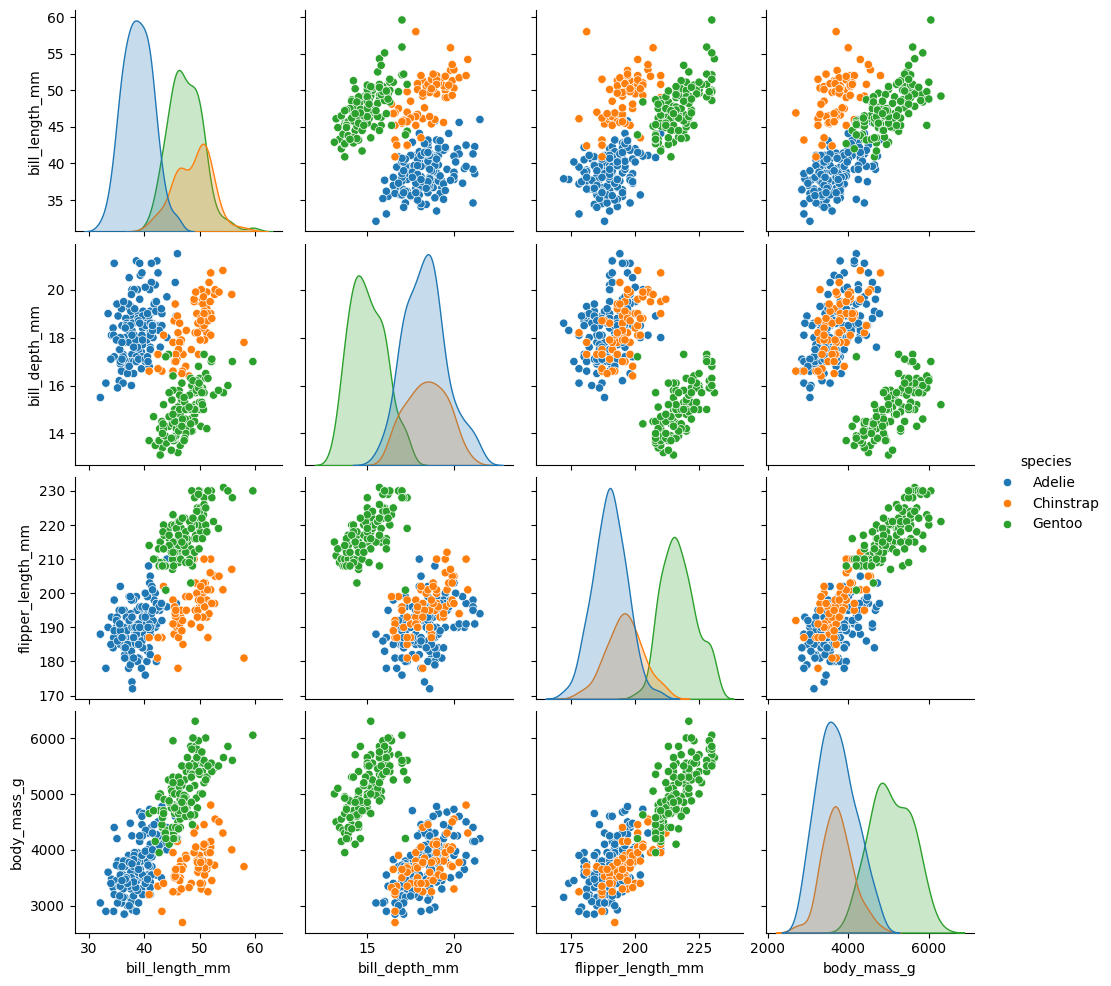

In [3]:
# 1.a create again a pairplot with hue on species
sns.pairplot(df, hue='species')

In [4]:
# 1.b create a correlation table by applying the .corr() method to a dataframe
df.select_dtypes(include='number').corr()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
bill_length_mm,1.000000,-0.235053,0.656181,0.595110
bill_depth_mm,-0.235053,1.000000,-0.583850,-0.471915
flipper_length_mm,0.656181,-0.583850,1.000000,0.871202
body_mass_g,0.595110,-0.471915,0.871202,1.000000


<Axes: >

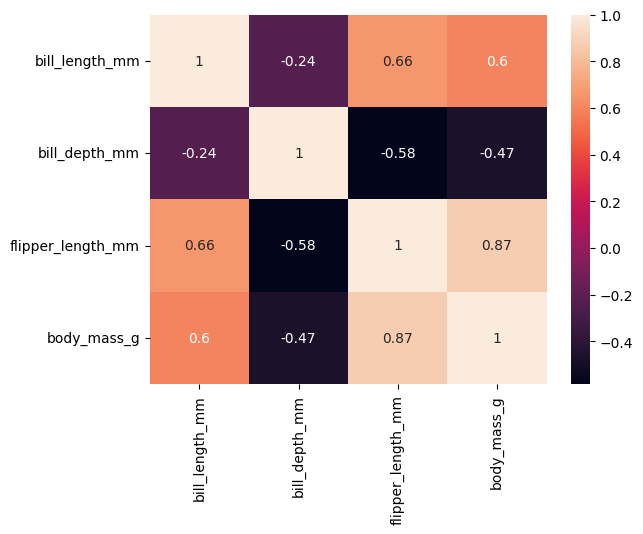

In [5]:
# 1.c add the correlation table to seaborns heatmap function
sns.heatmap(df.select_dtypes(include='number').corr(), annot=True)

## **Exercise 2**

In [6]:
# import libraries
import pandas as pd
import matplotlib.pyplot as plt

# load data and store in variable df
df = pd.read_csv('https://drive.google.com/uc?id=1Rzq2VqPVRM2kfMuh_jToJKzKUvBOC0vp')

df.head()

,id,price,neighbourhood_group_cleansed,latitude,longitude,bathrooms,availability_30,beds,bedrooms,review_scores_value,bed_type,minimum_nights,maximum_nights,availability_365,property_type,is_business_travel_ready,cleaning_fee,room_type,square_feet,guests_included
0,28684898,$50.00,Neukölln,52.473978,13.454423,1.0,18,2.0,2.0,9.0,Real Bed,1,13,73,Apartment,f,$0.00,Private room,NaN,1
1,22607348,$10.00,Treptow - Köpenick,52.468095,13.487103,1.0,0,1.0,1.0,9.0,Real Bed,30,1124,156,Apartment,f,NaN,Private room,NaN,1
2,21019199,$35.00,Neukölln,52.481810,13.437268,1.0,0,1.0,1.0,9.0,Real Bed,1,1125,0,Apartment,f,$15.00,Private room,NaN,1
3,21919556,$99.00,Pankow,52.537269,13.416036,2.0,0,2.0,2.0,NaN,Real Bed,14,41,35,Apartment,f,$50.00,Entire home/apt,NaN,1
4,4820648,$39.00,Friedrichshain-Kreuzberg,52.491483,13.387362,1.0,0,1.0,1.0,9.0,Real Bed,60,1125,289,Apartment,f,NaN,Entire home/apt,NaN,1


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13531 entries, 0 to 13530
Data columns (total 20 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   id                            13531 non-null  int64  
 1   price                         13531 non-null  object 
 2   neighbourhood_group_cleansed  13531 non-null  object 
 3   latitude                      13531 non-null  float64
 4   longitude                     13531 non-null  float64
 5   bathrooms                     13508 non-null  float64
 6   availability_30               13531 non-null  int64  
 7   beds                          13502 non-null  float64
 8   bedrooms                      13520 non-null  float64
 9   review_scores_value           10853 non-null  float64
 10  bed_type                      13531 non-null  object 
 11  minimum_nights                13531 non-null  int64  
 12  maximum_nights                13531 non-null  int64  
 13  a

In [8]:
# 2.a the price is currently stored as a string, for example: $1,000.00
# we need to remove the dollar sign and the comma, afterwars we can transform the column to type float
df['price'] =  df['price'].str.replace('$','')# replace dollar sign
df['price'] = df['price'].str.replace(',','') # replace comma
df['price'] = df['price'].astype(float) # transform to float

In [9]:
# 2.b the same can be done with the column cleaning_fee
df['cleaning_fee'] = df['cleaning_fee'].str.replace('$','')
df['cleaning_fee'] = df['cleaning_fee'].str.replace(',','')
df['cleaning_fee'] = df['cleaning_fee'].astype(float)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13531 entries, 0 to 13530
Data columns (total 20 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   id                            13531 non-null  int64  
 1   price                         13531 non-null  float64
 2   neighbourhood_group_cleansed  13531 non-null  object 
 3   latitude                      13531 non-null  float64
 4   longitude                     13531 non-null  float64
 5   bathrooms                     13508 non-null  float64
 6   availability_30               13531 non-null  int64  
 7   beds                          13502 non-null  float64
 8   bedrooms                      13520 non-null  float64
 9   review_scores_value           10853 non-null  float64
 10  bed_type                      13531 non-null  object 
 11  minimum_nights                13531 non-null  int64  
 12  maximum_nights                13531 non-null  int64  
 13  a

In [11]:
# 2.c some columns have a lot of missing values.
# try to understand how the following comand works.
# try to execute df.isna() only, then df.isna().sum() ...

df.isna().sum().sort_values(ascending=False)
# df.isna().sort_values(ascending=False)

,0
square_feet,13260
cleaning_fee,4272
review_scores_value,2678
beds,29
bathrooms,23
bedrooms,11
price,0
id,0
latitude,0
neighbourhood_group_cleansed,0


In [14]:
# 2.d fill ne missing values with the mean value, check with the above command that
# no missing values are left
df = df.fillna(df.select_dtypes('number').mean())
df.isna().sum().sort_values(ascending=False)

,0
id,0
price,0
neighbourhood_group_cleansed,0
latitude,0
longitude,0
bathrooms,0
availability_30,0
beds,0
bedrooms,0
review_scores_value,0


In [16]:
# 2.d compute the corelations and look which features have a high corelation with price
# df.corr().style.background_gradient()
df.select_dtypes(include='number').corr().style.background_gradient()

,id,price,latitude,longitude,bathrooms,availability_30,beds,bedrooms,review_scores_value,minimum_nights,maximum_nights,availability_365,cleaning_fee,square_feet,guests_included
id,1.000000,0.036903,0.000890,-0.021492,-0.009163,0.124149,-0.054175,-0.078555,0.034258,-0.039821,-0.007156,-0.063357,-0.081665,-0.002346,-0.073048
price,0.036903,1.000000,-0.000523,-0.043415,0.056410,0.113626,0.093743,0.105298,-0.030973,0.006582,-0.000835,0.103613,0.243949,0.011013,0.093485
latitude,0.000890,-0.000523,1.000000,-0.103196,0.002291,-0.007762,0.015873,0.010359,-0.007964,0.012127,0.008208,0.004840,0.028375,-0.010605,0.030783
longitude,-0.021492,-0.043415,-0.103196,1.000000,0.000848,-0.052582,-0.005210,0.008254,0.017827,-0.024320,-0.004821,-0.082404,-0.045074,0.000221,-0.001144
bathrooms,-0.009163,0.056410,0.002291,0.000848,1.000000,0.036989,0.267756,0.300103,-0.003459,-0.004560,-0.003453,0.039848,0.110863,0.041437,0.159584
availability_30,0.124149,0.113626,-0.007762,-0.052582,0.036989,1.000000,0.128834,0.040929,-0.054270,0.032532,0.012623,0.541278,0.074724,0.001048,0.082160
beds,-0.054175,0.093743,0.015873,-0.005210,0.267756,0.128834,1.000000,0.615204,-0.089233,0.010716,-0.006461,0.191947,0.219194,0.077113,0.445370
bedrooms,-0.078555,0.105298,0.010359,0.008254,0.300103,0.040929,0.615204,1.000000,-0.021724,0.000833,-0.002958,0.075513,0.211437,0.076173,0.372031
review_scores_value,0.034258,-0.030973,-0.007964,0.017827,-0.003459,-0.054270,-0.089233,-0.021724,1.000000,-0.013551,-0.006510,-0.090955,-0.090198,-0.007284,-0.062850
minimum_nights,-0.039821,0.006582,0.012127,-0.024320,-0.004560,0.032532,0.010716,0.000833,-0.013551,1.000000,-0.001543,0.088981,0.084426,-0.005234,0.012834


In [25]:
# load functions
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import numpy as np

In [18]:
# 2.e define a feature dataframe with 3 features and the target column price
# create a train and test dataset
X = df[['square_feet','cleaning_fee', 'latitude','longitude','bedrooms','review_scores_value','minimum_nights']]
y_target = df['price']

X_train, X_test, y_train, y_test = train_test_split(X, y_target, test_size=0.3)

In [19]:
# 2.f train a linear regression model
model = LinearRegression()
model.fit(X_train, y_train)

model.predict(X_train)

array([75.95768488, 55.06921926, 69.00905908, ..., 68.35117867,
       30.61545475, 73.30254846])

In [26]:
# 2.g test your model
y_predict = model.predict(X_test)
mse = mean_squared_error(y_test, y_predict)
rmse = np.sqrt(mse)
print(rmse)

308.5411822334513


In [ ]:
# 2.h include more features to your model and look how the root mean square error gets lower

# NEXT WEEK